# Razón Estandarizada de Morbilidad [Colombia]

La Razón Estandarizada de Morbilidad (REM) es un indicador epidemiológico que permite comparar la carga de una enfermedad entre diferentes territorios, ajustando por el tamaño de su población. Se obtiene al dividir el número de casos observados en cada departamento, en el caso de **Colombia**, por el número de casos esperados, calculados a partir de la tasa nacional de incidencia. Este indicador facilita identificar áreas con exceso o déficit de morbilidad respecto al promedio nacional, evidenciando territorios donde el riesgo de enfermar es mayor o menor al esperado. En el caso del dengue, la REM resulta útil para reconocer patrones espaciales de transmisión y priorizar regiones que requieren mayores esfuerzos de vigilancia y control vectorial.

$$
REM_{Colombia} = \frac{O_{Colombia}}{E_{Colombia}}
$$

donde:
- $ O_{Colombia} $= número de casos observados en la zona,
- $ E_{Colombia} $= número de casos esperados según la tasa nacional de incidencia.


In [1]:
# [Configuración] Imports
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# [Configuración] Lectura de archivos

## Archivos CSV de REM
rem_clasico = pd.read_csv(r"REM/REM_Clasico_COL.csv")
rem_grave = pd.read_csv(r"REM/REM_Grave_COL.csv")
rem_periodo_grave = pd.read_csv(r"REM/REM_PERIODO_Grave_COL.csv")
rem_periodo_clasico = pd.read_csv(r"REM/REM_PERIODO_Clasico_COL.csv")

## Archivo shapefile de departamentos
gdf = gpd.read_file("Mapas/Departamento/MGN_ADM_DPTO_POLITICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'dpto_cnmbr': 'departamento'})

In [3]:
# [Funciones] Graficar panel de mapas REM por años

def graficar_panel_rem(df, shp, evento=None):
    """
    Grafica un panel de mapas del REM de dengue en Colombia por años,
    cada uno con su escala individual.
    
    Parámetros:
        df (pd.DataFrame): datos con columnas [departamento, año, rem].
        shp (gpd.GeoDataFrame): shapefile de Colombia.
        evento (str, opcional): tipo de evento ("Clásico", "Grave", etc.).
    """

    # === 1. Normalizar nombres ===
    df["departamento"] = df["departamento"].str.upper().str.strip()
    shp["departamento"] = shp["departamento"].str.upper().str.strip()

    # === 2. Lista de años únicos ordenados ===
    anios = sorted(df["año"].unique())

    # === 3. Crear figure y ejes ===
    ncols = 4
    nrows = (len(anios) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))
    axes = axes.flatten()

    for i, anio in enumerate(anios):
        ax = axes[i]
        df_anio = df[df["año"] == anio]
        gdf_anio = shp.merge(df_anio, left_on="departamento", right_on="departamento", how="left")
        gdf_anio["REM"] = gdf_anio["REM"].fillna(0)

        vmin = gdf_anio["REM"].min()
        vmax = gdf_anio["REM"].max()

        # Graficar mapa
        gdf_anio.plot(
            column="REM",
            cmap="Blues",
            linewidth=0.5,
            edgecolor="0.8",
            vmin=vmin, vmax=vmax,
            ax=ax,
            legend=True,
            legend_kwds={"shrink": 0.6, "label": "REM"}
        )

        ax.set_title(str(anio), fontsize=12, fontweight="bold")
        ax.axis("off")

    # Ocultar subplots vacíos
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    
    titulo = f"REM del dengue {evento or 'general'} en Colombia ({anios[0]}–{anios[-1]})"
    fig.suptitle(titulo, fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    

# [Funciones] Graficar panel de mapas REM por periodos.

def graficar_periodos(df, shp, evento=None):
    """
    Grafica un panel de mapas del REM de dengue en Colombia por periiodos,
    cada uno con su escala individual.
    
    Parámetros:
        df (pd.DataFrame): datos con columnas [departamento, periodo, rem].
        shp (gpd.GeoDataFrame): shapefile de Colombia.
        evento (str, opcional): tipo de evento ("Clásico", "Grave", etc.).
    """

    
    df["departamento"] = df["departamento"].str.upper().str.strip()
    shp["departamento"] = shp["departamento"].str.upper().str.strip()

    
    anios = sorted(df["periodo"].unique())

    
    ncols = 3
    nrows = (len(anios) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))
    axes = axes.flatten()

    for i, anio in enumerate(anios):
        ax = axes[i]
        df_anio = df[df["periodo"] == anio]
        gdf_anio = shp.merge(df_anio, left_on="departamento", right_on="departamento", how="left")
        gdf_anio["REM"] = gdf_anio["REM"].fillna(0)

        vmin = gdf_anio["REM"].min()
        vmax = gdf_anio["REM"].max()

        # Graficar mapa
        gdf_anio.plot(
            column="REM",
            cmap="Blues",
            linewidth=0.5,
            edgecolor="0.8",
            vmin=vmin, vmax=vmax,
            ax=ax,
            legend=True,
            legend_kwds={"shrink": 0.6, "label": "REM"}
        )

        ax.set_title(str(anio), fontsize=12, fontweight="bold")
        ax.axis("off")

    # Ocultar subplots vacíos
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    
    titulo = f"REM del dengue {evento or 'general'} en Colombia ({anios[0]}–{anios[-1]})"
    fig.suptitle(titulo, fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    


## **REM por Año**

In [4]:
graficar_panel_rem(rem_clasico, gdf, evento="Clásico")

En los primeros años, los valores de REM se mantienen relativamente moderados, con una concentración de mayor morbilidad en los departamentos del centro y sur del país. A partir de **2018**, se observan incrementos notorios en territorios como **Guaviare** y **Amazonas**, donde los valores alcanzan niveles significativamente superiores a 1, reflejando un riesgo relativo elevado frente al promedio nacional. En **2019** y **2023** esta tendencia se acentúa, consolidando a la **región amazónica** como un foco persistente de alta carga relativa. En contraste, algunos años intermedios, como **2017** y **2020**, presentan valores más bajos y una distribución más uniforme, sugiriendo un comportamiento menos concentrado de la morbilidad por dengue.

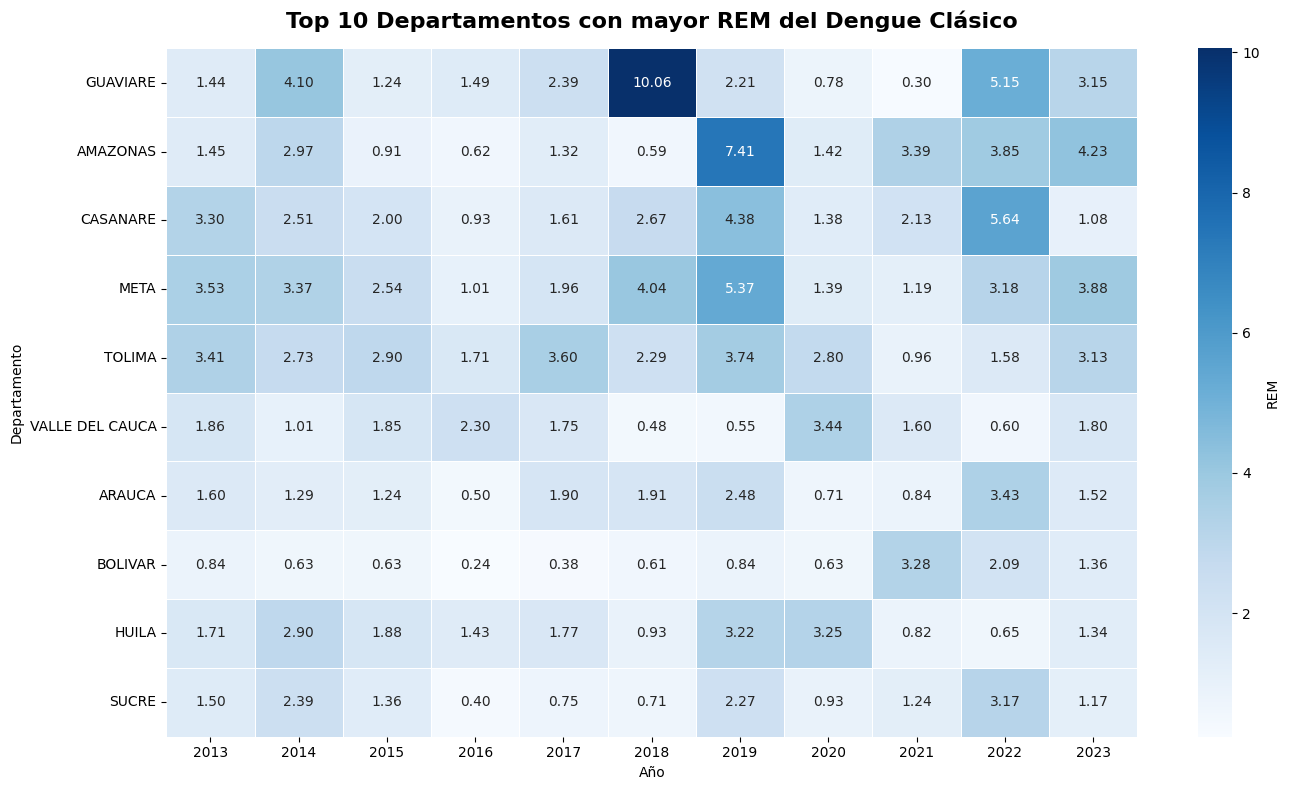

In [ ]:
tabla_clasico_rem = rem_clasico.pivot(
    index="departamento", 
    columns="anio", 
    values="rem"
).fillna(0)

top10_departamentos = (
    tabla_clasico_rem.max(axis=1)  
    .nlargest(10)                  
    .index                         
)
tabla_top10 = tabla_clasico_rem.loc[top10_departamentos]

plt.figure(figsize=(14, 8))
sns.heatmap(
    tabla_top10,
    cmap="Blues",
    annot=True,
    fmt=".2f",             
    linewidths=0.5,
    cbar_kws={'label': 'REM'}
)

plt.title("Top 10 Departamentos con mayor REM del Dengue Clásico", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()


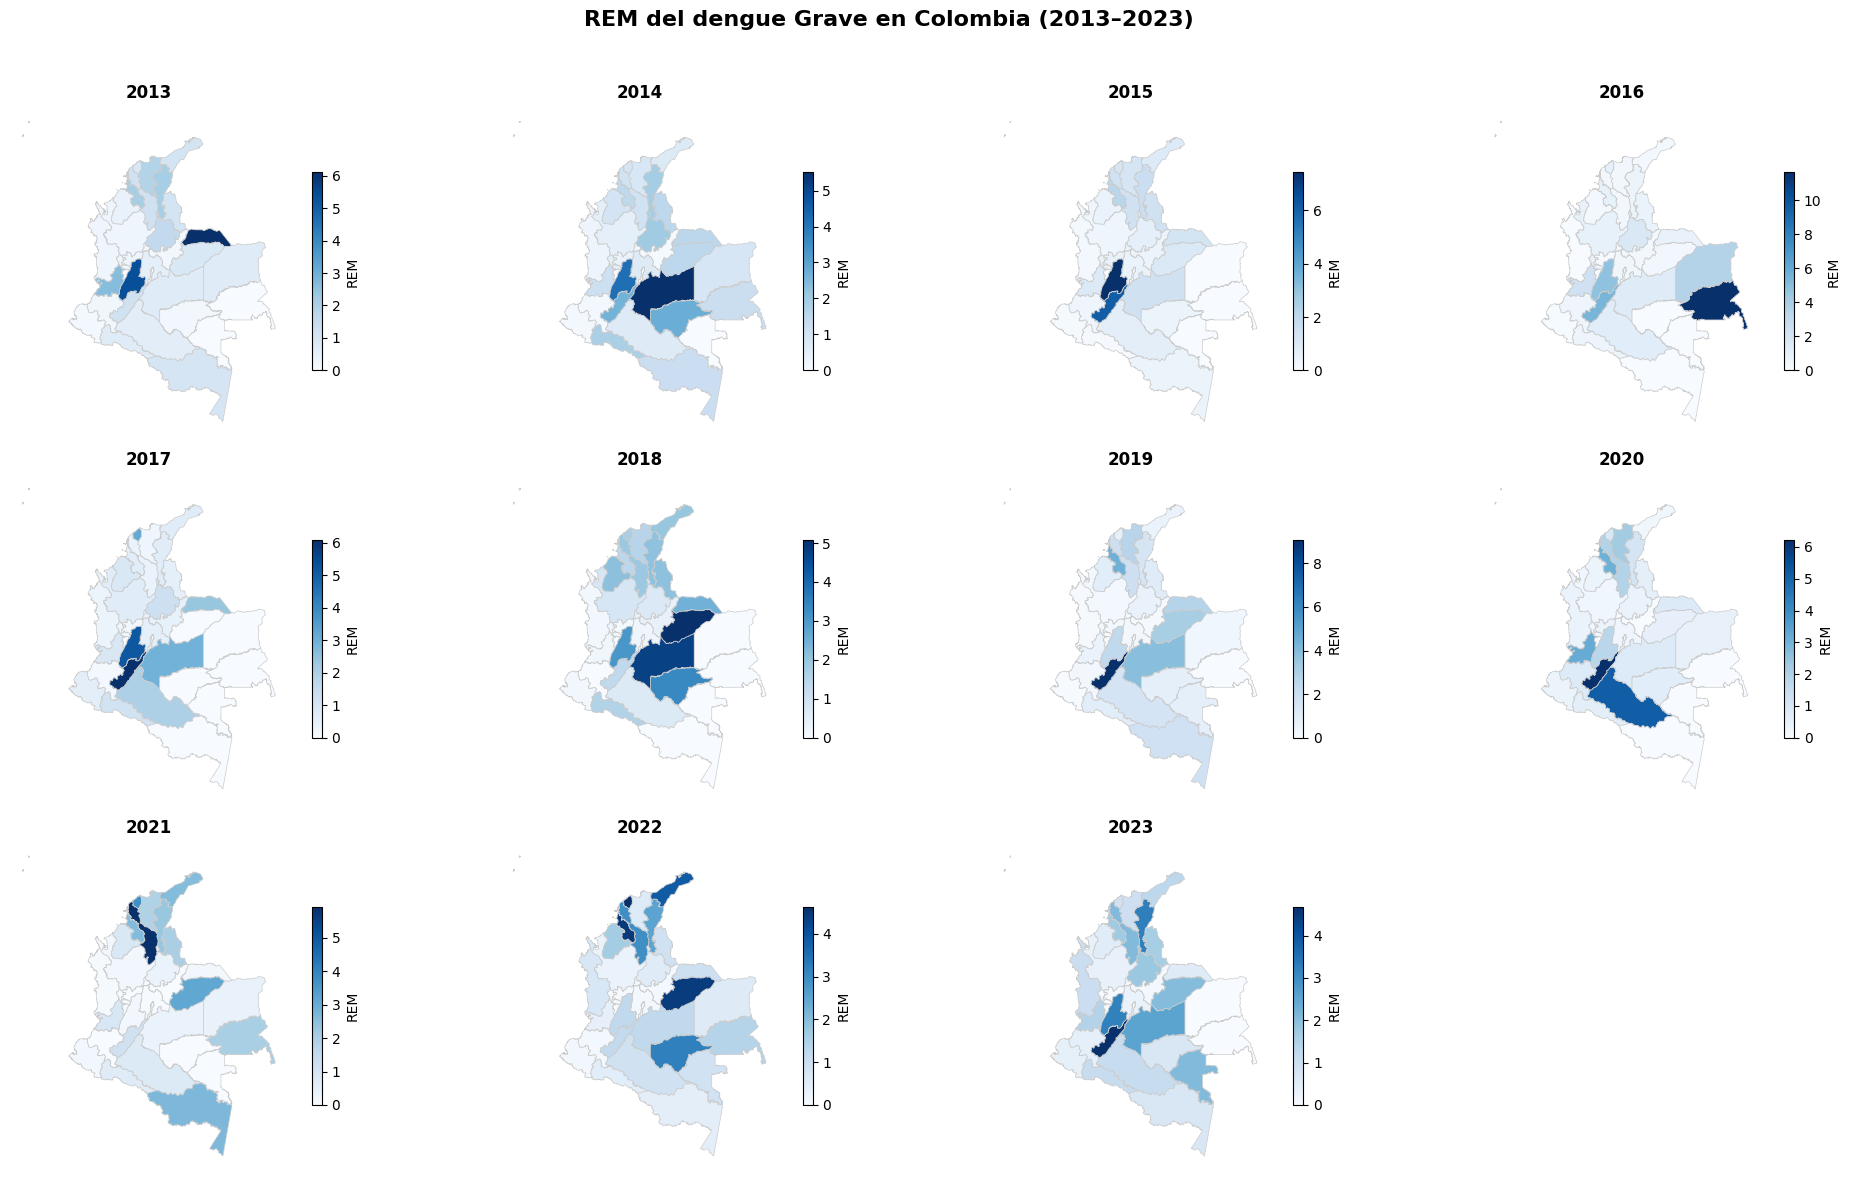

In [9]:
graficar_panel_rem(rem_grave, gdf, evento="Grave")

Durante los primeros años, en el caso del dengue grave, particularmente en **2015**, destacan **Tolima** y **Huila** con valores de **REM superiores a 5**, lo que refleja que la proporción de casos graves fue mucho mayor a la esperada en estas zonas. En **2016** se observa un cambio de foco hacia la región de la **Orinoquía**, mientras que en **2017** los valores disminuyen de manera considerable. No obstante, en **2018** reaparecen concentraciones elevadas en algunos departamentos del centro y suroccidente, con **REM = 4**, lo que indica una reactivación relativa de las formas graves de la enfermedad. 

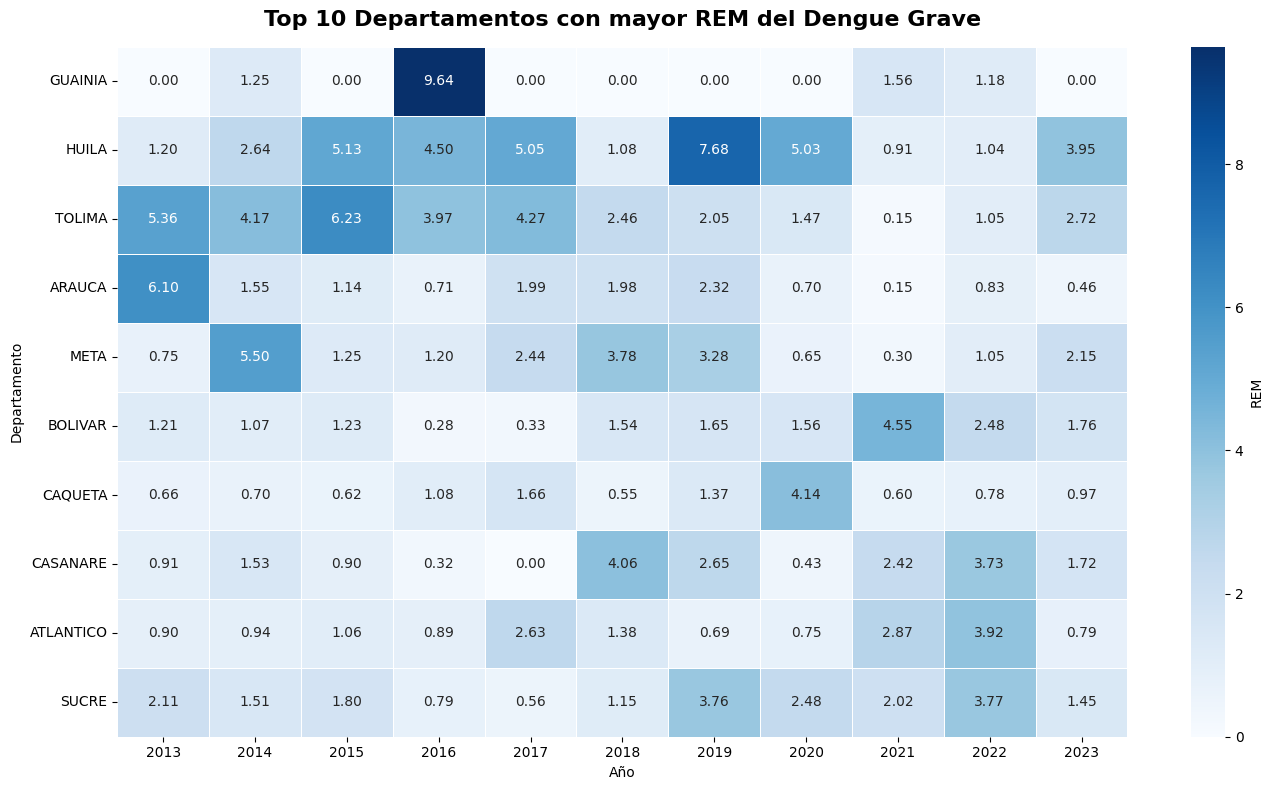

In [ ]:
tabla_grave_rem = rem_grave.pivot(
    index="departamento", 
    columns="anio", 
    values="rem"
).fillna(0)

top10_departamentos = (
    tabla_grave_rem.max(axis=1)  # máximo de cada depto en todos los años
    .nlargest(10)                  # los 10 más altos
    .index                         # nombres de los deptos
)
tabla_top10 = tabla_grave_rem.loc[top10_departamentos]

plt.figure(figsize=(14, 8))
sns.heatmap(
    tabla_top10,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'REM'}
)

plt.title("Top 10 Departamentos con mayor REM del Dengue Grave", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()


## **REM por Periodo**


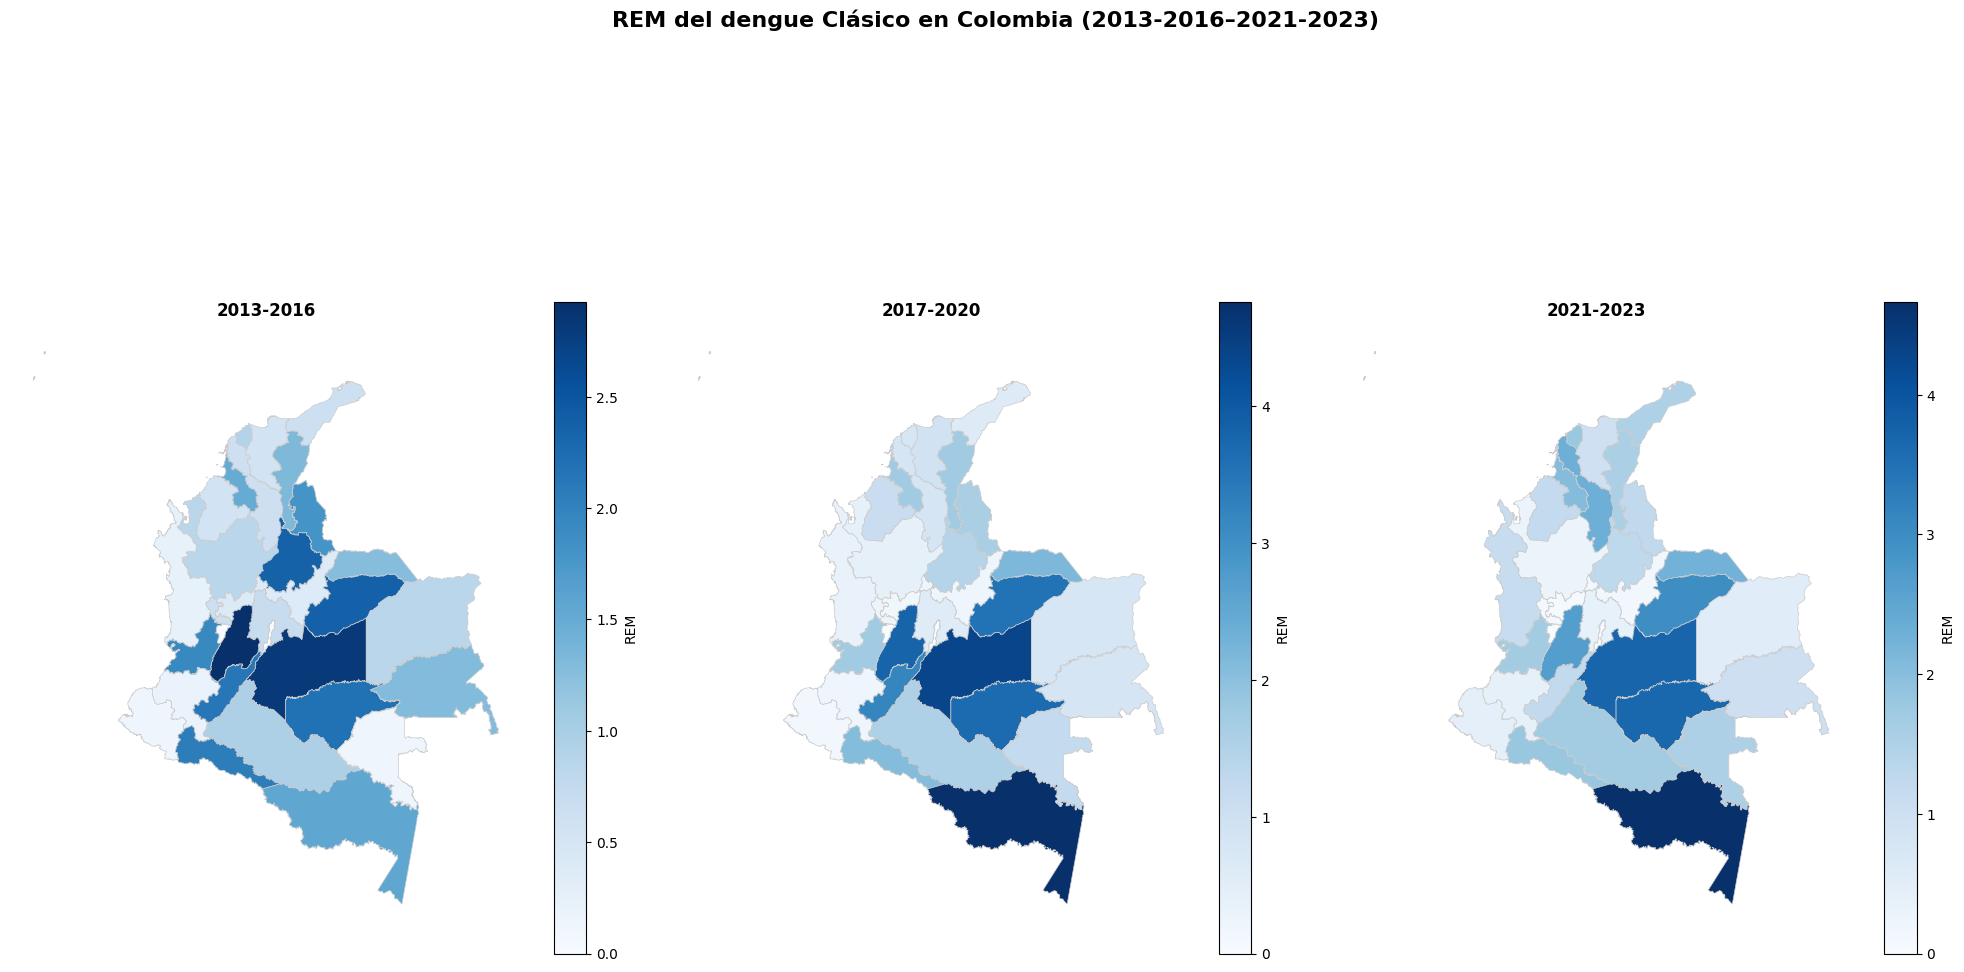

In [13]:
graficar_periodos(rem_periodo_clasico, gdf, evento="Clásico")

Durante el primer periodo **(2013--2016)**, se observa una alta carga relativa en varios departamentos del centro del país, destacándose valores elevados en **Tolima** y **Meta**. En el segundo periodo **(2017--2020)**, la distribución se desplaza hacia regiones del suroriente, con un aumento notable en departamentos amazónicos. Finalmente, entre **(2021--2023)**, la persistencia del dengue clásico se mantiene con focos en el oriente y sur del país, mostrando un patrón más estable, aunque con intensidades aún elevadas en regiones amazónicas.

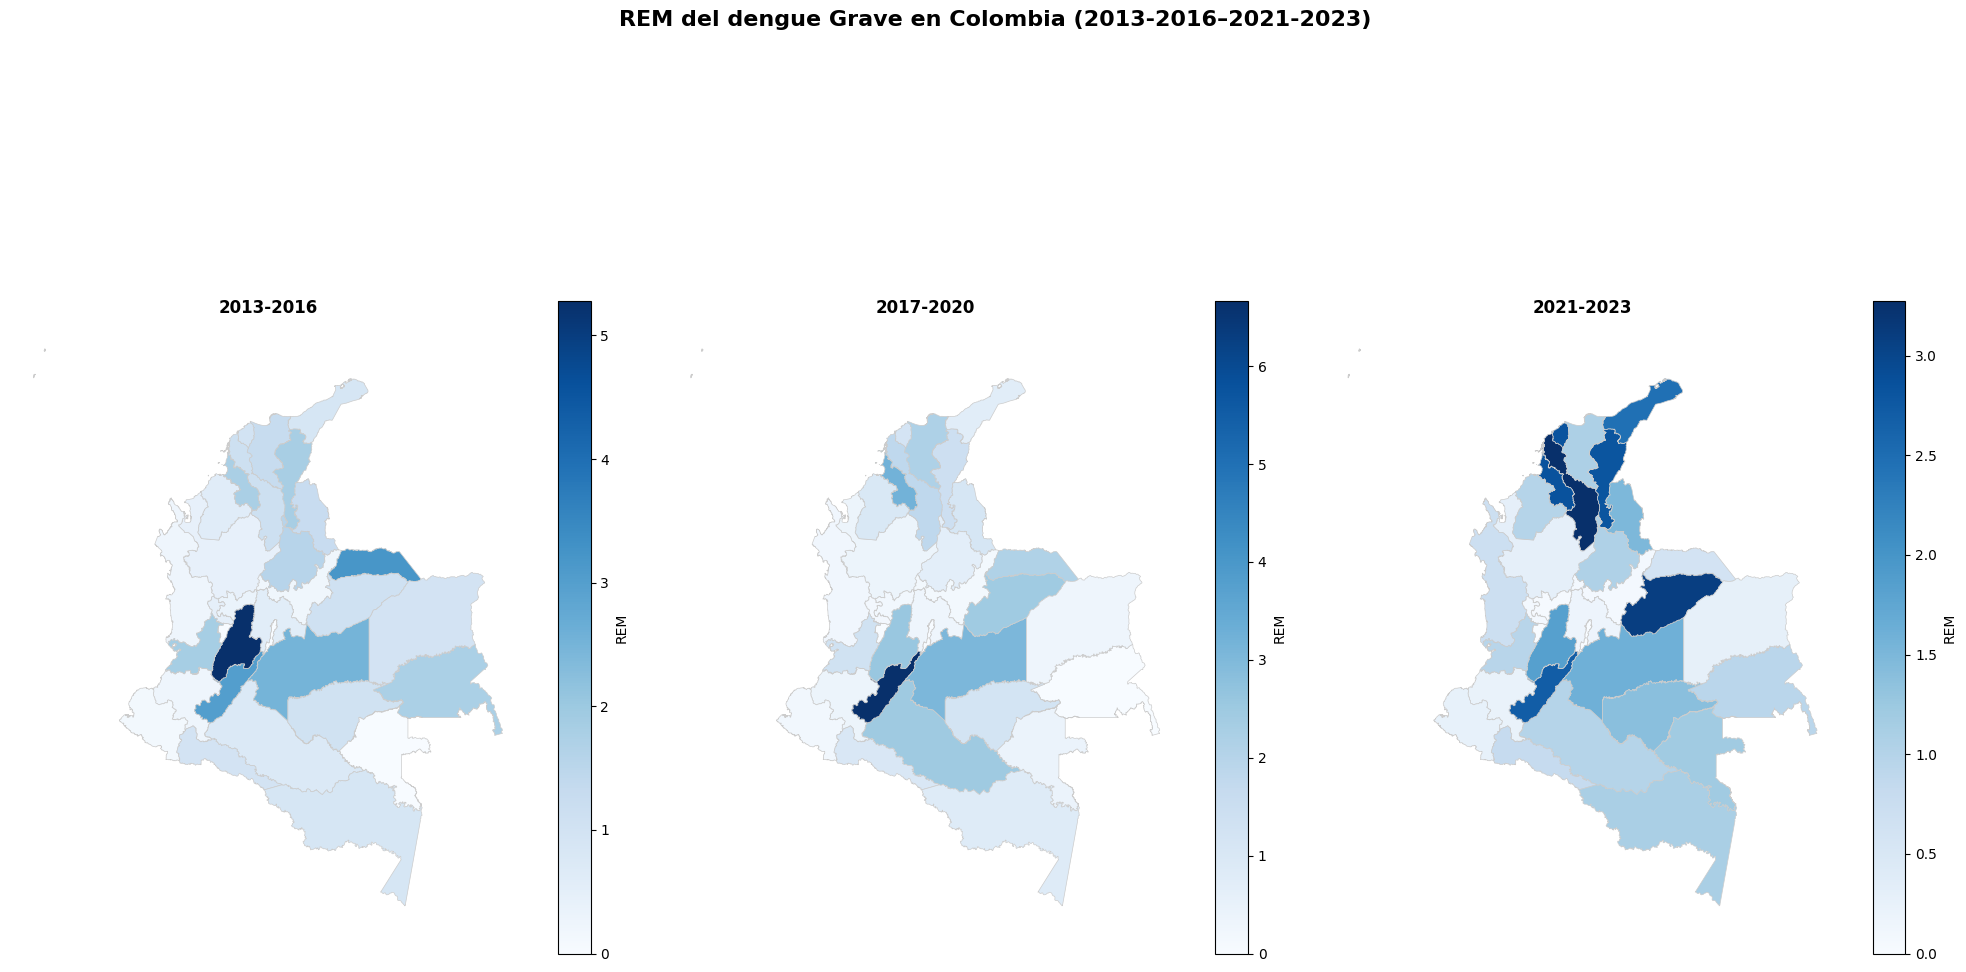

In [12]:

graficar_periodos(rem_periodo_grave, gdf, evento="Grave")

En cuanto al dengue grave, en periodo **(2013--2016)** se evidencia una mayor intensidad en departamentos del centro y oriente del país, con focos en **Tolima** y **Guainía**. El periodo **(2017--2020)** muestra una concentración destacada en el suroccidente, con mayor intensidad en el departamento de **Huila**. Por último, en **(2021--2023)**, los focos de dengue grave se distribuyen hacia el norte y oriente del país, con presencia en departamentos de la **Costa Caribe** y regiones de los **Llanos Orientales**, aunque con menores valores de REM en comparación con el primer periodo.